# Imports and Setup

Bagian ini memuat:
- Library inti (numpy/pandas) dan tooling (Path/joblib)
- Konfigurasi untuk skenario **GLOBAL** (user_id hanya untuk grouping & split, bukan fitur)
- Utility untuk evaluasi metrik dan tuning threshold

- Semua nama kolom kini snake_case (mis. `user_id`, `stress_level`, `created_at`, `study_hour_per_day`).
- Kolom `is_restored` adalah metadata input/restore dan **tidak** dipakai sebagai fitur model (dipakai sebagai quality flag melalui sample_weight).


In [17]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.simplefilter("ignore")

import json
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import requests
from sqlalchemy import create_engine, text

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import ParameterGrid

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from dotenv import load_dotenv
from pathlib import Path
load_dotenv(Path.cwd().joinpath("../../.env").resolve(), override=True)

# =============================================================================
# 0) CONFIG
# =============================================================================

# Manual Train / Train Manual
DEFAULT_PARAMETERS = {
    "data_source": "csv",
    "dataset_path": "../datasets/stress_forecast.csv",
    "user_id": 0,
    "window_size": 60,
    "enable_eda": True,
}
PARAMETERS = globals().get("PARAMETERS") or DEFAULT_PARAMETERS



data_source = PARAMETERS.get("data_source", os.getenv("DATA_SOURCE", "db"))
global_days_limit = PARAMETERS.get("global_days_limit")

# primary output (existing pattern)
output_path = PARAMETERS.get("output_path")

# secondary output (ngikutin cara yang sama: bisa dioverride dari PARAMETERS / env)
secondary_output_path = PARAMETERS.get(
    "secondary_output_path",
    os.getenv("SECONDARY_OUTPUT_PATH")
)

metrics_output_path = PARAMETERS.get("metrics_output_path")
dataset_path = PARAMETERS.get("dataset_path")

def _resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for parent in [cwd, *cwd.parents]:
        if (parent / "nostressia-backend" / "app" / "models_ml").exists():
            return parent
    return cwd

repo_root = _resolve_repo_root()

# default primary output (existing)
default_model_out = repo_root / "nostressia-backend" / "app" / "models_ml" / "global_forecast.joblib"
MODEL_OUT = Path(output_path) if output_path else default_model_out

# default secondary output (dibuat pakai "cara" yang sama: repo_root + relative path)
default_secondary_model_out = (
    repo_root
    / "nostressia-machine-learning"
    / "Stress-Forecast"
    / "models"
    / "global_forecast.joblib"
)

SECOND_MODEL_OUT = (
    Path(secondary_output_path)
    if secondary_output_path
    else default_secondary_model_out
)

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT", "3306")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

BACKEND_BASE_URL = os.getenv("BACKEND_BASE_URL")
INTERNAL_TOKEN = os.getenv("INTERNAL_TOKEN")

DATE_COL   = "date"
USER_COL   = "user_id"             # used only for split/grouping (never as features)
TARGET_COL = "stress_level"        # 0..2

RESTORE_COL = "is_restored"
# RESTORE_STRATEGY: "sample_weight" or "filter"
RESTORE_STRATEGY = "sample_weight"
RESTORE_WEIGHT = 0.5

WINDOW   = 7
TEST_LEN = 12

# CV windows (relative index inside each user's train_pool), end exclusive
VAL_WINDOWS = [(12, 24), (18, 30)]

# Threshold search for decision rule from probabilities
THRESHOLDS = np.linspace(0.05, 0.95, 19)

# Blend config: p = alpha*p_ml + (1-alpha)*p_markov
USE_BLEND = True
ALPHAS = np.linspace(0.0, 1.0, 11)

RANDOM_STATE = 26

# Optional: add behavior lag1 if hour-like numeric columns exist
USE_BEHAVIOR_LAG1 = True


# =============================================================================
# Utilities
# =============================================================================
def eval_bin(y_true, y_pred):
    return {
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1":  float(f1_score(y_true, y_pred, zero_division=0)),
    }

def tune_thr_from_proba(y_true, p_high, thresholds=THRESHOLDS):
    best_thr, best_f1 = None, -1.0
    for thr in thresholds:
        pred = (p_high >= thr).astype(int)
        f1 = float(f1_score(y_true, pred, zero_division=0))
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return float(best_thr), float(best_f1)

def safe_class_counts(y: np.ndarray):
    y = np.asarray(y).astype(int)
    return {0: int((y == 0).sum()), 1: int((y == 1).sum())}

def pick_existing_behavior_cols(df: pd.DataFrame):
    """
    Detect hour-like numeric columns for optional lag1 behavior features.
    This remains no-leak because shift(1) is applied during feature engineering.
    """
    exclude = {DATE_COL, USER_COL, TARGET_COL}
    numeric = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
    hour_like = [c for c in numeric if ("hour" in c.lower()) or ("hours" in c.lower())]

    known = [
        "study_hour_per_day",
        "sleep_hour_per_day",
        "social_hour_per_day",
        "physical_activity_hour_per_day",
        "extracurricular_hour_per_day",
    ]
    for c in known:
        if c in numeric and c not in hour_like:
            hour_like.append(c)

    return hour_like


# Load and Explore Dataset

Tujuan bagian ini:
- Load dataset dari `DATA_PATH`
- Validasi kolom penting: `date`, `user_id`, `stress_level`
- Sort per user berdasarkan waktu
- Deteksi `BEHAVIOR_COLS` (opsional) untuk fitur `lag1_*`


In [18]:
# LOAD REALTIME DATA

# LOAD FROM CSV
def _load_global_from_csv(path):
    if not path:
        raise RuntimeError("dataset_path wajib untuk data_source=csv.")
    return pd.read_csv(path)

def _load_global_from_db(days_limit):
    if not all([DB_HOST, DB_USER, DB_PASSWORD, DB_NAME]):
        raise RuntimeError("DB config tidak lengkap untuk load data global.")
    url = (
        f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}"
        f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )
    engine = create_engine(url)
    where_clause = ""
    params = {}
    if days_limit:
        where_clause = "WHERE date >= DATE_SUB(CURDATE(), INTERVAL :days DAY)"
        params["days"] = int(days_limit)
    query = f"""
        SELECT
            user_id,
            date,
            stress_level,
            gpa,
            extracurricular_hour_per_day,
            physical_activity_hour_per_day,
            sleep_hour_per_day,
            study_hour_per_day,
            social_hour_per_day,
            emoji,
            is_restored
        FROM stress_levels
        {where_clause}
        ORDER BY user_id, date
    """
    with engine.connect() as conn:
        return pd.read_sql(text(query), conn, params=params)

def _load_global_from_api(days_limit):
    if not BACKEND_BASE_URL:
        raise RuntimeError("BACKEND_BASE_URL belum di-set untuk mode API.")
    url = f"{BACKEND_BASE_URL.rstrip('/')}/api/ml/training-data/global"
    headers = {}
    if INTERNAL_TOKEN:
        headers["X-Internal-Token"] = INTERNAL_TOKEN
    params = {}
    if days_limit:
        params["days_limit"] = int(days_limit)
    resp = requests.get(url, headers=headers, params=params, timeout=30)
    resp.raise_for_status()
    payload = resp.json()
    return pd.DataFrame(payload.get("data", []))

if data_source == "db":
    df = _load_global_from_db(global_days_limit)
elif data_source == "api":
    df = _load_global_from_api(global_days_limit)
elif data_source == "csv":
    df = _load_global_from_csv(dataset_path)
else:
    raise ValueError(f"Unknown data_source: {data_source}")

if df.empty:
    raise ValueError("SKIPPED_INSUFFICIENT_DATA: global dataset kosong.")

if RESTORE_COL not in df.columns:
    df[RESTORE_COL] = 0
df[RESTORE_COL] = df[RESTORE_COL].fillna(0).astype(int)

for required_col in [DATE_COL, USER_COL, TARGET_COL]:
    if required_col not in df.columns:
        raise KeyError(f"Required column '{required_col}' not found in dataset.")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="raise")
df = df.sort_values([USER_COL, DATE_COL]).reset_index(drop=True)

target_ok = df[TARGET_COL].dropna().between(0, 2).all()
if not target_ok:
    raise ValueError(f"'{TARGET_COL}' must be within range 0..2")

BEHAVIOR_COLS = pick_existing_behavior_cols(df) if USE_BEHAVIOR_LAG1 else []

print("DATA_SOURCE   :", data_source)
print("ROWS          :", len(df))
print("USERS         :", df[USER_COL].nunique())
print("DATE_RANGE    :", str(df[DATE_COL].min().date()), "->", str(df[DATE_COL].max().date()))
print("TARGET_COL    :", TARGET_COL)
print("BEHAVIOR_COLS :", BEHAVIOR_COLS)

print("\nHEAD:")
display(df.head())


DATA_SOURCE   : csv
ROWS          : 472
USERS         : 5
DATE_RANGE    : 2025-11-21 -> 2026-02-23
TARGET_COL    : stress_level
BEHAVIOR_COLS : ['extracurricular_hour_per_day', 'physical_activity_hour_per_day', 'sleep_hour_per_day', 'study_hour_per_day', 'social_hour_per_day']

HEAD:


,stress_level_id,user_id,date,stress_level,gpa,extracurricular_hour_per_day,physical_activity_hour_per_day,sleep_hour_per_day,study_hour_per_day,social_hour_per_day,emoji,is_restored,created_at
0,1,1,2025-11-21,1,3.82,0.0,0.5,7.0,7.0,2.0,2,0,2025-11-21 23:29:33
1,2,1,2025-11-22,0,3.82,0.0,1.0,9.0,2.0,5.0,1,0,2025-11-22 20:23:04
2,3,1,2025-11-23,0,3.82,0.0,3.0,9.0,1.0,6.0,0,0,2025-11-23 20:42:45
3,4,1,2025-11-24,1,3.82,0.0,0.5,8.0,7.0,5.0,2,0,2025-11-24 23:29:32
4,5,1,2025-11-25,1,3.82,0.0,1.0,7.0,7.0,4.0,2,0,2025-11-25 23:38:40


# Exploratory Data Analysis (EDA)

Ringkasan cepat yang relevan:
- Distribusi `stress_level` (0–2) sebelum dibinarisasi
- Distribusi jumlah data per user untuk memastikan split time-based aman


TARGET_DIST (0..2): {0: 195, 1: 151, 2: 126}


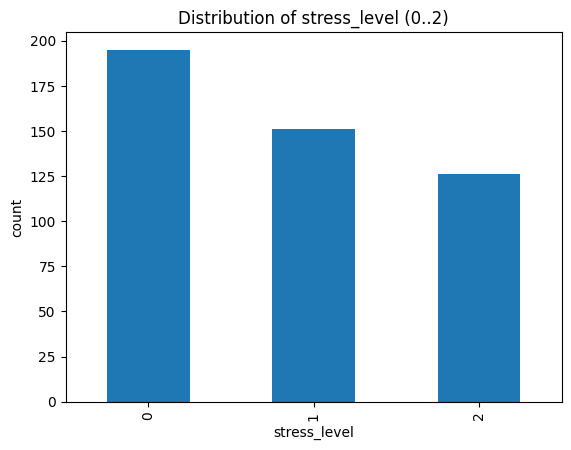


ROWS_PER_USER: {2: 95, 3: 95, 1: 94, 4: 94, 5: 94}


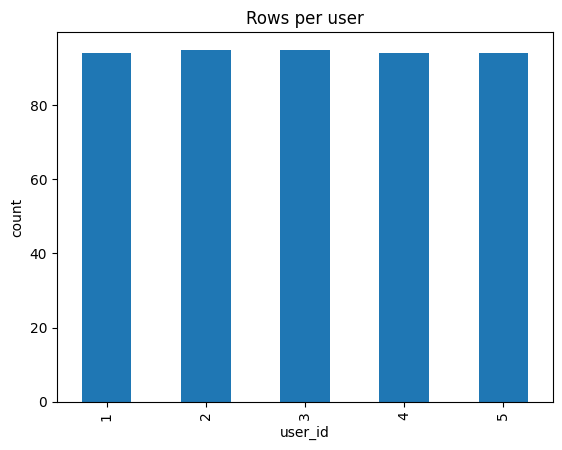

RESTORED_SUM: 0
RESTORED_RATE: 0.0
GAP_DAYS_STATS: {'count': 467.0, 'mean': 1.0, 'std': 0.0, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 1.0, 'max': 1.0}


In [19]:
ENABLE_EDA = PARAMETERS.get("enable_eda", False)

# EDA QUICK CHECKS
target_counts = df[TARGET_COL].value_counts().sort_index()
print("TARGET_DIST (0..2):", target_counts.to_dict())

if ENABLE_EDA:
    import matplotlib.pyplot as plt

    plt.figure()
    target_counts.plot(kind="bar")
    plt.title(f"Distribution of {TARGET_COL} (0..2)")
    plt.xlabel(TARGET_COL)
    plt.ylabel("count")
    plt.show()

user_counts = df[USER_COL].value_counts()
print("\nROWS_PER_USER:", user_counts.to_dict())

if ENABLE_EDA:
    plt.figure()
    user_counts.sort_index().plot(kind="bar")
    plt.title("Rows per user")
    plt.xlabel(USER_COL)
    plt.ylabel("count")
    plt.show()

# Restored counts
print("RESTORED_SUM:", int(df[RESTORE_COL].sum()))
print("RESTORED_RATE:", float(df[RESTORE_COL].mean()))

# Gap days stats (per user)
df_sorted = df.sort_values([USER_COL, DATE_COL]).copy()
df_sorted["gap_days"] = df_sorted.groupby(USER_COL)[DATE_COL].diff().dt.days
gap_stats = df_sorted["gap_days"].dropna().describe()
print("GAP_DAYS_STATS:", gap_stats.to_dict())


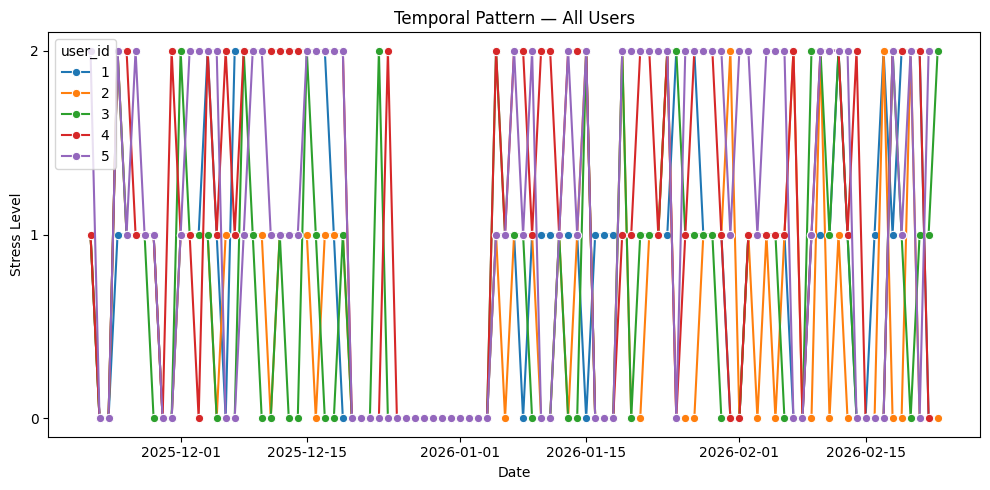

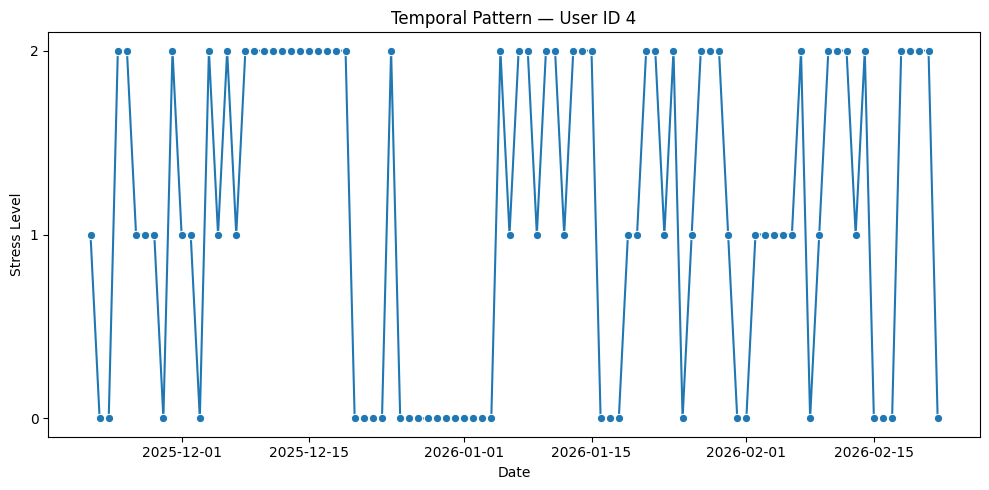

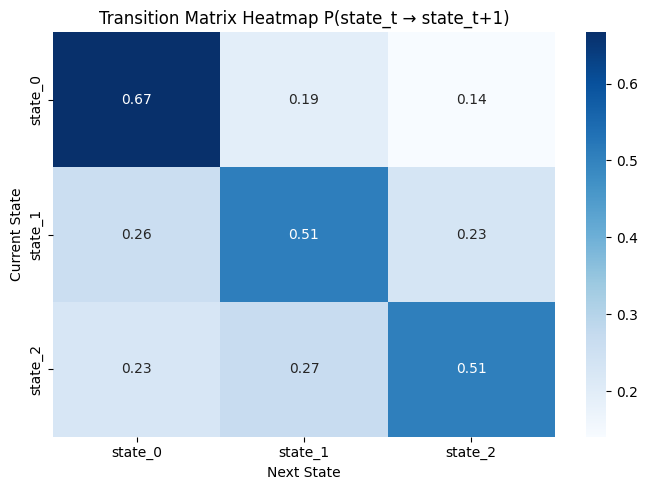

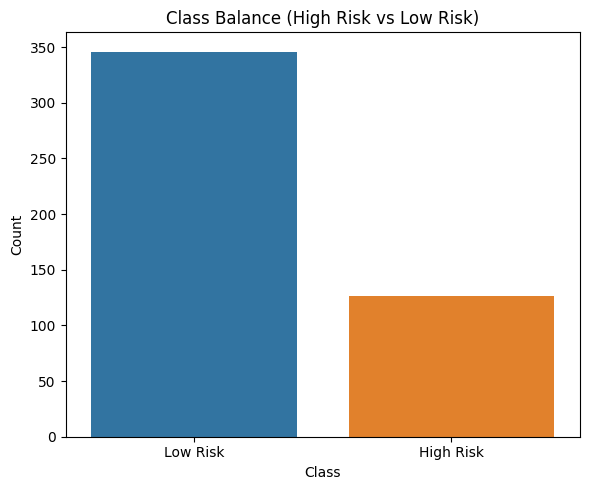

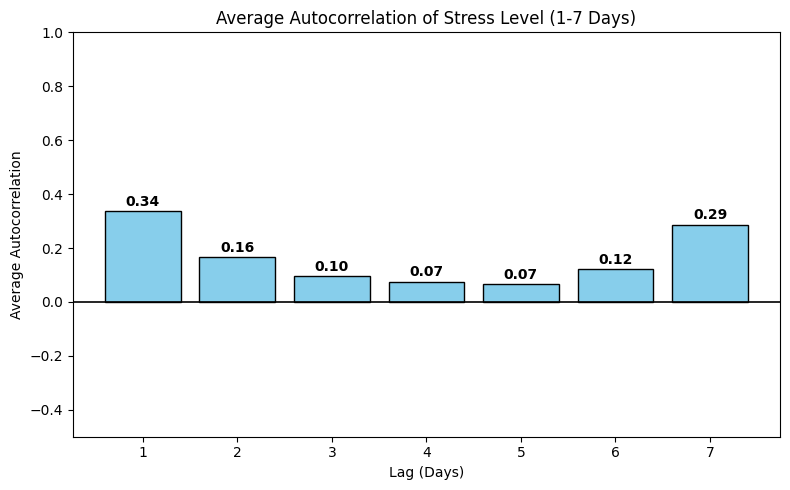

In [34]:
if ENABLE_EDA:
    # Plot Pack Forecast
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    plot_df = df.sort_values([USER_COL, DATE_COL]).copy()

    # 1) Temporal Pattern (all users)
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=plot_df, x=DATE_COL, y=TARGET_COL, hue=USER_COL, marker="o", palette="tab10")
    plt.title("Temporal Pattern — All Users")
    plt.xlabel("Date")
    plt.ylabel("Stress Level")
    plt.yticks([0, 1, 2])
    plt.tight_layout()
    plt.show()

    # 1b) Temporal Pattern — User ID 4 Only
    df_user4 = plot_df[plot_df[USER_COL] == 4]
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_user4, x=DATE_COL, y=TARGET_COL, marker="o", color="tab:blue")
    plt.title("Temporal Pattern — User ID 4")
    plt.xlabel("Date")
    plt.ylabel("Stress Level")
    plt.yticks([0, 1, 2])
    plt.tight_layout()
    plt.show()

    # 2) Transition Matrix Heatmap P(state_t -> state_t+1)
    trans = plot_df.copy()
    trans["next_state"] = trans.groupby(USER_COL)[TARGET_COL].shift(-1)
    trans = trans.dropna(subset=["next_state"])
    matrix = pd.crosstab(trans[TARGET_COL], trans["next_state"])
    matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)
    matrix.index = [f"state_{int(x)}" for x in matrix.index]
    matrix.columns = [f"state_{int(x)}" for x in matrix.columns]

    plt.figure(figsize=(7, 5))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues")
    plt.title("Transition Matrix Heatmap P(state_t → state_t+1)")
    plt.xlabel("Next State")
    plt.ylabel("Current State")
    plt.tight_layout()
    plt.show()

    # 3) Class Balance (High Risk vs Low Risk)
    high = (plot_df[TARGET_COL] == 2).sum()
    low = (plot_df[TARGET_COL] != 2).sum()
    class_df = pd.DataFrame({"Class": ["Low Risk", "High Risk"], "Count": [low, high]})

    plt.figure(figsize=(6, 5))
    sns.barplot(data=class_df, x="Class", y="Count", hue="Class", legend=False)
    plt.title("Class Balance (High Risk vs Low Risk)")
    plt.tight_layout()
    plt.show()

    # 4) Autocorrelation Analysis (lag 1..7)
    lags = range(1, 8)
    acf_values = {lag: [] for lag in lags}
    for _, g in plot_df.groupby(USER_COL):
        if len(g) > max(lags):
            for lag in lags:
                corr = g[TARGET_COL].autocorr(lag=lag)
                if not np.isnan(corr):
                    acf_values[lag].append(corr)
    avg_acf = {lag: np.mean(vals) for lag, vals in acf_values.items() if vals}

    plt.figure(figsize=(8, 5))
    plt.bar(avg_acf.keys(), avg_acf.values(), color="skyblue", edgecolor="black")
    plt.title("Average Autocorrelation of Stress Level (1-7 Days)")
    plt.xlabel("Lag (Days)")
    plt.ylabel("Average Autocorrelation")
    plt.ylim(-0.5, 1)
    plt.axhline(0, color="black", linewidth=1.2)
    for lag, val in avg_acf.items():
        vpos = val + 0.02 if val >= 0 else val - 0.08
        plt.text(lag, vpos, f"{val:.2f}", ha="center", fontweight="bold")
    plt.tight_layout()
    plt.show()

# Data Preprocessing

Tahap ini melakukan **feature engineering tanpa leakage**:
- Fitur kalender: `dow`, `is_weekend`
- Fitur gap observasi: `gap_1..gap_WINDOW` (selisih hari antar observasi)
- Fitur lag target: `lag_sp_1..lag_sp_WINDOW`
- Rolling stats dari history yang berakhir di `t-1`
- (Opsional) `lag1_<behavior_col>` dari `t-1`
- Penanganan `is_restored`: default **sample_weight** lebih kecil (bisa diubah via `RESTORE_STRATEGY`)

Transformasi label:
- `y_bin = 1` jika `stress_level >= 1`
- `y_bin = 0` jika `stress_level == 0`


In [21]:
# FEATURE ENGINEERING
rows = []
for uid, g in df.groupby(USER_COL):
    g = g.sort_values(DATE_COL).reset_index(drop=True)

    # Calendar features
    g["dow"] = g[DATE_COL].dt.dayofweek.astype(int)  # 0..6
    g["is_weekend"] = (g["dow"] >= 5).astype(int)

    # Target lag features (t-1..t-W)
    for k in range(1, WINDOW + 1):
        g[f"lag_sp_{k}"] = g[TARGET_COL].shift(k)


    # Gap features (days since previous observations)
    g["gap_days"] = g[DATE_COL].diff().dt.days
    for k in range(1, WINDOW + 1):
        g[f"gap_{k}"] = g["gap_days"].shift(k - 1)

    # Behavior lag1 (t-1)
    if len(BEHAVIOR_COLS) > 0:
        for c in BEHAVIOR_COLS:
            g[f"lag1_{c}"] = g[c].shift(1)

    # Rolling stats from history ending at t-1
    sp_shift = g[TARGET_COL].shift(1)

    g["sp_mean"] = sp_shift.rolling(WINDOW).mean()
    g["sp_std"]  = sp_shift.rolling(WINDOW).std().fillna(0.0)
    g["sp_min"]  = sp_shift.rolling(WINDOW).min()
    g["sp_max"]  = sp_shift.rolling(WINDOW).max()

    g["count_high"] = (sp_shift >= 1).rolling(WINDOW).sum()
    g["count_low"]  = (sp_shift == 0).rolling(WINDOW).sum()

    # High streak (<= t-1)
    high = (sp_shift >= 1).astype(int).fillna(0).astype(int).tolist()
    streak, cur = [], 0
    for v in high:
        cur = cur + 1 if v == 1 else 0
        streak.append(cur)
    g["streak_high"] = streak

    # Transitions in history (<= t-1)
    diff = (sp_shift != sp_shift.shift(1)).astype(int)
    g["transitions"] = diff.rolling(WINDOW).sum()

    rows.append(g)

feat = pd.concat(rows, ignore_index=True)

# Binary labeling: y_bin = 1 if pred>=1 else 0
feat["y_bin"] = (feat[TARGET_COL] >= 1).astype(int)

# GLOBAL: never include USER_COL as a feature
feature_cols = (
    ["dow", "is_weekend"]
    + [f"lag_sp_{k}" for k in range(1, WINDOW + 1)]
    + [f"gap_{k}" for k in range(1, WINDOW + 1)]
    + [
        "sp_mean", "sp_std", "sp_min", "sp_max",
        "count_high", "count_low",
        "streak_high", "transitions",
    ]
)
if len(BEHAVIOR_COLS) > 0:
    feature_cols += [f"lag1_{c}" for c in BEHAVIOR_COLS]

# Drop rows without full history
feat = feat.dropna(subset=feature_cols + ["y_bin"]).reset_index(drop=True)


# Handle restored rows
if RESTORE_STRATEGY == "filter":
    feat = feat[feat[RESTORE_COL] == 0].reset_index(drop=True)
    feat["sample_weight"] = 1.0
elif RESTORE_STRATEGY == "sample_weight":
    feat["sample_weight"] = np.where(feat[RESTORE_COL] == 1, RESTORE_WEIGHT, 1.0)
else:
    feat["sample_weight"] = 1.0

print("ROWS_FEAT      :", len(feat))
print("USERS_FEAT     :", feat[USER_COL].nunique())
print("FEATURES_COUNT :", len(feature_cols))
print("BINARY_DIST    :", feat["y_bin"].value_counts().to_dict())

display(feat[[USER_COL, DATE_COL, TARGET_COL, "y_bin"] + feature_cols].head())


ROWS_FEAT      : 437
USERS_FEAT     : 5
FEATURES_COUNT : 29
BINARY_DIST    : {1: 252, 0: 185}


,user_id,date,stress_level,y_bin,dow,is_weekend,lag_sp_1,lag_sp_2,lag_sp_3,lag_sp_4,...,sp_max,count_high,count_low,streak_high,transitions,lag1_extracurricular_hour_per_day,lag1_physical_activity_hour_per_day,lag1_sleep_hour_per_day,lag1_study_hour_per_day,lag1_social_hour_per_day
0,1,2025-11-28,1,1,4,0,1.0,1.0,1.0,1.0,...,1.0,5.0,2.0,4,3.0,0.0,5.0,6.0,6.0,7.0
1,1,2025-11-29,0,0,5,1,1.0,1.0,1.0,1.0,...,1.0,5.0,2.0,5,2.0,0.0,5.0,10.0,6.0,5.0
2,1,2025-11-30,0,0,6,1,0.0,1.0,1.0,1.0,...,1.0,5.0,2.0,0,2.0,0.0,1.0,7.0,4.0,2.0
3,1,2025-12-01,1,1,0,0,0.0,0.0,1.0,1.0,...,1.0,5.0,2.0,0,2.0,0.0,1.0,8.0,3.0,1.0
4,1,2025-12-02,1,1,1,0,1.0,0.0,0.0,1.0,...,1.0,5.0,2.0,1,2.0,0.0,1.0,6.5,8.0,2.0


# Model Training and Evaluation

Cakupan:
1. Split time-based per user: `TEST = last TEST_LEN` per user  
2. Baseline L1 (Persistence): `y(t) = y(t-1)`  
3. Baseline L2 (Markov GLOBAL): `P(y_t | prev_high, dow)` + tuning threshold via pooled CV  
4. Model candidates (GLOBAL, tanpa user_id) + fair pooled CV + threshold tuning  
5. (Opsional) BLEND: `p = alpha*p_ml + (1-alpha)*p_markov`  
6. Leaderboard + simpan artifact model terbaik


In [22]:
# SPLIT (TIME-BASED PER USER)
train_idx, test_idx = [], []
min_train_rows = max(v1 for v0, v1 in VAL_WINDOWS)
per_user_train_pool = {}

for uid, g in feat.groupby(USER_COL):
    g = g.sort_values(DATE_COL).reset_index()  # keeps original feat index in 'index'
    n = len(g)
    test_start = n - TEST_LEN
    if test_start <= max(WINDOW, min_train_rows):
        print(f"SKIP_USER (too few rows for split/CV): {uid} n={n} TEST_LEN={TEST_LEN}")
        continue

    train_pool = g.iloc[:test_start]
    test_block = g.iloc[test_start:]

    per_user_train_pool[uid] = train_pool
    train_idx += train_pool["index"].tolist()
    test_idx  += test_block["index"].tolist()

train_pool_df = feat.loc[train_idx].copy()
test_df = feat.loc[test_idx].copy()

print("TRAINPOOL_ROWS :", len(train_pool_df))
print("TEST_ROWS      :", len(test_df))
print("TEST_DIST      :", test_df["y_bin"].value_counts().to_dict())

# Build pooled CV splits from windows inside each user's train_pool
cv_splits = []
for (v0, v1) in VAL_WINDOWS:
    tr_idx, va_idx = [], []
    ok = True
    for uid, tp in per_user_train_pool.items():
        tp = tp.reset_index(drop=True)
        if len(tp) < v1:
            ok = False
            break
        va = tp.iloc[v0:v1]
        tr = tp.iloc[:v0]
        tr_idx += tr["index"].tolist()
        va_idx += va["index"].tolist()
    if ok:
        cv_splits.append((tr_idx, va_idx))

if len(cv_splits) == 0:
    raise ValueError("CV windows cannot be formed. Reduce TEST_LEN or adjust VAL_WINDOWS.")

print("CV_FOLDS     :", len(cv_splits))
print("VAL_WINDOWS  :", VAL_WINDOWS)

X_trainpool = train_pool_df[feature_cols].copy()
y_trainpool = train_pool_df["y_bin"].astype(int).values

X_test = test_df[feature_cols].copy()
y_test = test_df["y_bin"].astype(int).values


TRAINPOOL_ROWS : 377
TEST_ROWS      : 60
TEST_DIST      : {1: 34, 0: 26}
CV_FOLDS     : 2
VAL_WINDOWS  : [(12, 24), (18, 30)]


In [23]:
# BASELINE L1: PERSISTENCE (y(t)=y(t-1))
pred_persist = (test_df["lag_sp_1"] >= 1).astype(int).values
persist_metrics = eval_bin(y_test, pred_persist)

print("TEST_ACC :", persist_metrics["acc"])
print("TEST_F1  :", persist_metrics["f1"])


TEST_ACC : 0.6666666666666666
TEST_F1  : 0.7142857142857143


In [24]:
# BASELINE L2: MARKOV GLOBAL (prev_high, dow) + THR TUNING (POOLED CV)
def train_markov_global(df_train):
    # counts: prev(2) x dow(7) x y(2)
    counts = np.zeros((2, 7, 2), dtype=int)
    prev = (df_train["lag_sp_1"] >= 1).astype(int).values
    dow  = df_train["dow"].astype(int).values
    yb   = df_train["y_bin"].astype(int).values
    for p, d, y in zip(prev, dow, yb):
        counts[p, d, y] += 1
    # Laplace smoothing
    probs = (counts + 1) / (counts.sum(axis=2, keepdims=True) + 2)
    return probs

def markov_proba(probs, df_eval):
    prev = (df_eval["lag_sp_1"] >= 1).astype(int).values
    dow  = df_eval["dow"].astype(int).values
    return np.array([probs[p, d, 1] for p, d in zip(prev, dow)], dtype=float)

# Threshold tuning on pooled CV (no leakage)
cv_true, cv_phigh = [], []
for _, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
    tr_df = feat.loc[tr_idx]
    va_df = feat.loc[va_idx]
    probs = train_markov_global(tr_df)
    p = markov_proba(probs, va_df)
    cv_true.append(va_df["y_bin"].astype(int).values)
    cv_phigh.append(p)

cv_true = np.concatenate(cv_true)
cv_phigh = np.concatenate(cv_phigh)

thr_mk, cv_f1_mk = tune_thr_from_proba(cv_true, cv_phigh)

# Train Markov on full train_pool and evaluate on test
probs_full = train_markov_global(train_pool_df)
p_test_mk = markov_proba(probs_full, test_df)
pred_test_mk = (p_test_mk >= thr_mk).astype(int)
markov_metrics = eval_bin(y_test, pred_test_mk)

print("CV_POOLED_DIST  :", safe_class_counts(cv_true))
print("BEST_THR_MARKOV :", thr_mk)
print("CV_POOLED_F1    :", cv_f1_mk)
print("TEST_ACC_MARKOV :", markov_metrics["acc"])
print("TEST_F1_MARKOV  :", markov_metrics["f1"])


CV_POOLED_DIST  : {0: 61, 1: 59}
BEST_THR_MARKOV : 0.5499999999999999
CV_POOLED_F1    : 0.7441860465116279
TEST_ACC_MARKOV : 0.6333333333333333
TEST_F1_MARKOV  : 0.6764705882352942


In [25]:
# PREPROCESS (GLOBAL: NO user_id)
cat_cols = ["dow"]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
    ],
    remainder="drop",
)


In [26]:
# CANDIDATE MODELS
CANDIDATES = {
    "LogReg": (
        LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
        {"clf__C": [0.03, 0.1, 0.3, 1.0, 3.0], "clf__solver": ["liblinear"]},
    ),
    "DecisionTree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        {"clf__max_depth": [2, 3, 4, 6, None], "clf__min_samples_leaf": [1, 2, 4, 8]},
    ),
    "RandomForest": (
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
        {"clf__n_estimators": [200, 400, 800], "clf__max_depth": [None, 6, 10],
         "clf__min_samples_leaf": [1, 2, 4], "clf__max_features": ["sqrt"]},
    ),
    "ExtraTrees": (
        ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
        {"clf__n_estimators": [200, 400, 800], "clf__max_depth": [None, 6, 10],
         "clf__min_samples_leaf": [1, 2, 4], "clf__max_features": ["sqrt"]},
    ),
    "HistGB": (
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        {"clf__learning_rate": [0.03, 0.05, 0.1], "clf__max_depth": [2, 3], "clf__max_leaf_nodes": [15, 31, 63]},
    ),
    "GradBoost": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"clf__learning_rate": [0.03, 0.05, 0.1], "clf__n_estimators": [100, 200, 400], "clf__max_depth": [2, 3]},
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {"clf__learning_rate": [0.03, 0.05, 0.1, 0.3], "clf__n_estimators": [50, 100, 200, 400]},
    ),
    "BaggingTree": (
        BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        {"clf__n_estimators": [50, 100, 200],
         "clf__estimator__max_depth": [2, 3, 4, None],
         "clf__estimator__min_samples_leaf": [1, 2, 4]},
    ),
    "LinearSVC_Calibrated": (
        CalibratedClassifierCV(
            estimator=LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
            method="sigmoid",
            cv=3,
        ),
        {"clf__estimator__C": [0.03, 0.1, 0.3, 1.0, 3.0]},
    ),
}

print("MODELS     :", list(CANDIDATES.keys()))
print("USE_BLEND  :", USE_BLEND)
print("ALPHAS     :", ALPHAS.tolist())
print("THRESHOLDS :", THRESHOLDS.tolist())


MODELS     : ['LogReg', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'HistGB', 'GradBoost', 'AdaBoost', 'BaggingTree', 'LinearSVC_Calibrated']
USE_BLEND  : True
ALPHAS     : [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
THRESHOLDS : [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.39999999999999997, 0.44999999999999996, 0.49999999999999994, 0.5499999999999999, 0.6, 0.65, 0.7, 0.75, 0.7999999999999999, 0.85, 0.9, 0.95]


In [27]:
# TRAIN + TUNE (FAIR POOLED CV)
def make_pipe(clf):
    return Pipeline([("prep", preprocess), ("clf", clf)])

def make_calibrated_svc(cv_k: int):
    return CalibratedClassifierCV(
        estimator=LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        method="sigmoid",
        cv=cv_k,
    )

def pooled_cv_best(model_name: str, base_clf, grid):
    best = None

    for params in ParameterGrid(grid):
        y_list, pml_list, pmk_list = [], [], []
        valid_folds = 0

        for (tr_idx, va_idx) in cv_splits:
            tr_df = feat.loc[tr_idx]
            va_df = feat.loc[va_idx]

            Xtr = tr_df[feature_cols].copy()
            ytr = tr_df["y_bin"].astype(int).values
            Xva = va_df[feature_cols].copy()
            yva = va_df["y_bin"].astype(int).values

            if len(np.unique(ytr)) < 2:
                continue

            mk_probs = train_markov_global(tr_df)
            p_mk = markov_proba(mk_probs, va_df)

            try:
                if model_name == "LinearSVC_Calibrated":
                    counts = safe_class_counts(ytr)
                    min_class = min(counts.values())
                    cv_k = int(min(3, min_class))
                    if cv_k < 2:
                        continue
                    clf = make_calibrated_svc(cv_k=cv_k)
                    pipe = make_pipe(clf)
                else:
                    pipe = make_pipe(base_clf)

                pipe.set_params(**params)
                sample_weight = tr_df.get("sample_weight")
                if sample_weight is not None:
                    try:
                        pipe.fit(Xtr, ytr, clf__sample_weight=sample_weight)
                    except TypeError:
                        pipe.fit(Xtr, ytr)
                else:
                    pipe.fit(Xtr, ytr)
                p_ml = pipe.predict_proba(Xva)[:, 1]
            except Exception:
                valid_folds = 0
                break

            y_list.append(yva)
            pml_list.append(p_ml)
            pmk_list.append(p_mk)
            valid_folds += 1

        if valid_folds == 0:
            continue

        y_all = np.concatenate(y_list)
        pml_all = np.concatenate(pml_list)
        pmk_all = np.concatenate(pmk_list)

        if USE_BLEND:
            local_best = None
            for alpha in ALPHAS:
                p_blend = alpha * pml_all + (1.0 - alpha) * pmk_all
                thr, cv_f1 = tune_thr_from_proba(y_all, p_blend)
                if (local_best is None) or (cv_f1 > local_best["cv_f1"]):
                    local_best = {"alpha": float(alpha), "thr": float(thr), "cv_f1": float(cv_f1)}
            record = {"params": params, **local_best, "valid_folds": int(valid_folds)}
        else:
            thr, cv_f1 = tune_thr_from_proba(y_all, pml_all)
            record = {"params": params, "alpha": 1.0, "thr": float(thr), "cv_f1": float(cv_f1), "valid_folds": int(valid_folds)}

        if (best is None) or (record["cv_f1"] > best["cv_f1"]):
            best = record

    return best


rows = []
for model_name, (clf, grid) in CANDIDATES.items():
    best = pooled_cv_best(model_name, clf, grid)
    if best is None:
        print("SKIP_MODEL :", model_name, "(no valid params/folds)")
        continue

    try:
        if model_name == "LinearSVC_Calibrated":
            counts = safe_class_counts(y_trainpool)
            min_class = min(counts.values())
            cv_k = int(min(3, min_class))
            if cv_k < 2:
                raise ValueError("TrainPool is too small for calibrated SVC (cv_k < 2).")
            final_clf = make_calibrated_svc(cv_k=cv_k)
        else:
            final_clf = clf

        final_pipe = make_pipe(final_clf)
        final_pipe.set_params(**best["params"])
        sample_weight = train_pool_df.get("sample_weight")
        if sample_weight is not None:
            try:
                final_pipe.fit(X_trainpool, y_trainpool, clf__sample_weight=sample_weight)
            except TypeError:
                final_pipe.fit(X_trainpool, y_trainpool)
        else:
            final_pipe.fit(X_trainpool, y_trainpool)
        p_test_ml = final_pipe.predict_proba(X_test)[:, 1]
    except Exception:
        print("SKIP_MODEL :", model_name, "(failed final training)")
        continue

    p_test_mk_full = markov_proba(probs_full, test_df)

    alpha = float(best["alpha"])
    p_test_final = alpha * p_test_ml + (1.0 - alpha) * p_test_mk_full
    pred_test_final = (p_test_final >= best["thr"]).astype(int)

    test_metrics = eval_bin(y_test, pred_test_final)

    rows.append({
        "model": model_name,
        "cv_f1": float(best["cv_f1"]),
        "alpha": float(best["alpha"]),
        "thr": float(best["thr"]),
        "valid_folds": int(best["valid_folds"]),
        "test_f1": float(test_metrics["f1"]),
        "test_acc": float(test_metrics["acc"]),
        "params": dict(best["params"]),
        "pipe": final_pipe,
    })

    print("MODEL        :", model_name)
    print("  CV_F1      :", float(best["cv_f1"]))
    print("  VALID_FOLDS:", int(best["valid_folds"]))
    print("  ALPHA      :", float(best["alpha"]))
    print("  THR        :", float(best["thr"]))
    print("  TEST_F1    :", float(test_metrics["f1"]))
    print("  TEST_ACC   :", float(test_metrics["acc"]))
    print("  PARAMS     :", dict(best["params"]))


MODEL        : LogReg
  CV_F1      : 0.7936507936507936
  VALID_FOLDS: 2
  ALPHA      : 0.6000000000000001
  THR        : 0.44999999999999996
  TEST_F1    : 0.7605633802816901
  TEST_ACC   : 0.7166666666666667
  PARAMS     : {'clf__C': 0.03, 'clf__solver': 'liblinear'}
MODEL        : DecisionTree
  CV_F1      : 0.7796610169491526
  VALID_FOLDS: 2
  ALPHA      : 0.30000000000000004
  THR        : 0.65
  TEST_F1    : 0.7333333333333333
  TEST_ACC   : 0.7333333333333333
  PARAMS     : {'clf__max_depth': 3, 'clf__min_samples_leaf': 8}
MODEL        : RandomForest
  CV_F1      : 0.773109243697479
  VALID_FOLDS: 2
  ALPHA      : 0.4
  THR        : 0.7
  TEST_F1    : 0.7
  TEST_ACC   : 0.7
  PARAMS     : {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
MODEL        : ExtraTrees
  CV_F1      : 0.7610619469026548
  VALID_FOLDS: 2
  ALPHA      : 0.5
  THR        : 0.75
  TEST_F1    : 0.7037037037037037
  TEST_ACC   : 0.7333333333333333
  

In [28]:
# LEADERBOARD + SELECT BEST
base_rows = [
    {"model": "Baseline-Persist", "cv_f1": np.nan, "alpha": np.nan, "thr": np.nan,
     "test_f1": persist_metrics["f1"], "test_acc": persist_metrics["acc"], "params": None},
    {"model": "Baseline-Markov",  "cv_f1": cv_f1_mk, "alpha": 0.0, "thr": thr_mk,
     "test_f1": markov_metrics["f1"], "test_acc": markov_metrics["acc"], "params": {"markov": "prev_high+dow"}},
]

all_rows = base_rows + [{k: v for k, v in r.items() if k != "pipe"} for r in rows]
all_sorted = sorted(all_rows, key=lambda r: r["test_f1"], reverse=True)

for r in all_sorted:
    print(
        "MODEL=", r["model"],
        "| CV_F1=", r["cv_f1"],
        "| TEST_F1=", r["test_f1"],
        "| TEST_ACC=", r["test_acc"],
        "| ALPHA=", r["alpha"],
        "| THR=", r["thr"],
        "| PARAMS=", r["params"]
    )

if len(rows) == 0:
    print("\nRESULT: No valid ML model. Saving Markov as best.")
    best_name = "MarkovGlobal"
    best_obj = {
        "type": "global_markov",
        "thr": float(thr_mk),
        "probs": probs_full,
        "meta": {
            "note": "No ML model succeeded; Markov saved as best",
            "target": "y_bin=(stress_level>=1)",
            "date_col": DATE_COL,
            "user_col": USER_COL,
            "target_col": TARGET_COL,
            "window": WINDOW,
            "test_len": TEST_LEN,
            "val_windows": VAL_WINDOWS,
            "thresholds": THRESHOLDS.tolist(),
            "use_blend": USE_BLEND,
            "alphas": ALPHAS.tolist(),
            "behavior_cols": BEHAVIOR_COLS,
            "feature_cols": feature_cols,
            "gap_features": [f"gap_{k}" for k in range(1, WINDOW + 1)],
            "restore_col": RESTORE_COL,
            "restore_strategy": RESTORE_STRATEGY,
            "restore_weight": RESTORE_WEIGHT,
            "user_id_used": False,
        },
    }
else:
    best_ml = sorted(rows, key=lambda r: r["test_f1"], reverse=True)[0]

    print("\nRESULT")
    print("BEST_ML_MODEL   :", best_ml["model"])
    print("BEST_ML_TEST_F1 :", best_ml["test_f1"])
    print("BEST_ML_TEST_ACC:", best_ml["test_acc"])
    print("BEST_ML_ALPHA   :", best_ml["alpha"])
    print("BEST_ML_THR     :", best_ml["thr"])
    print("BEST_ML_PARAMS  :", best_ml["params"])

    if best_ml["test_f1"] > markov_metrics["f1"]:
        best_name = best_ml["model"]
        best_obj = {
            "type": "global_blend_model" if USE_BLEND else "global_ml_model",
            "pipe": best_ml["pipe"],
            "alpha": float(best_ml["alpha"]),
            "thr": float(best_ml["thr"]),
            "markov_probs": probs_full,
            "meta": {
                "note": "GLOBAL (no user_id). Uses p = alpha*p_ml + (1-alpha)*p_markov" if USE_BLEND else "GLOBAL (no user_id). Uses ML prob only",
                "target": "y_bin=(stress_level>=1)",
                "date_col": DATE_COL,
                "user_col": USER_COL,
                "target_col": TARGET_COL,
                "window": WINDOW,
                "test_len": TEST_LEN,
                "val_windows": VAL_WINDOWS,
                "thresholds": THRESHOLDS.tolist(),
                "use_blend": USE_BLEND,
                "alphas": ALPHAS.tolist(),
                "behavior_cols": BEHAVIOR_COLS,
                "feature_cols": feature_cols,
            "gap_features": [f"gap_{k}" for k in range(1, WINDOW + 1)],
            "restore_col": RESTORE_COL,
            "restore_strategy": RESTORE_STRATEGY,
            "restore_weight": RESTORE_WEIGHT,
            "user_id_used": False,
            },
        }
        print("SELECTED_BEST   : ML/BLEND (beats Markov on TEST)")
    else:
        best_name = "MarkovGlobal"
        best_obj = {
            "type": "global_markov",
            "thr": float(thr_mk),
            "probs": probs_full,
            "meta": {
                "note": "Markov remains best on TEST for this dataset",
                "target": "y_bin=(stress_level>=1)",
                "date_col": DATE_COL,
                "user_col": USER_COL,
                "target_col": TARGET_COL,
                "window": WINDOW,
                "test_len": TEST_LEN,
                "val_windows": VAL_WINDOWS,
                "thresholds": THRESHOLDS.tolist(),
                "use_blend": USE_BLEND,
                "alphas": ALPHAS.tolist(),
                "behavior_cols": BEHAVIOR_COLS,
                "feature_cols": feature_cols,
            "gap_features": [f"gap_{k}" for k in range(1, WINDOW + 1)],
            "restore_col": RESTORE_COL,
            "restore_strategy": RESTORE_STRATEGY,
            "restore_weight": RESTORE_WEIGHT,
            "user_id_used": False,
            },
        }
        print("SELECTED_BEST   : MARKOV (still best on TEST)")


MODEL= AdaBoost | CV_F1= 0.7619047619047619 | TEST_F1= 0.7692307692307693 | TEST_ACC= 0.75 | ALPHA= 0.7000000000000001 | THR= 0.5499999999999999 | PARAMS= {'clf__learning_rate': 0.3, 'clf__n_estimators': 400}
MODEL= LogReg | CV_F1= 0.7936507936507936 | TEST_F1= 0.7605633802816901 | TEST_ACC= 0.7166666666666667 | ALPHA= 0.6000000000000001 | THR= 0.44999999999999996 | PARAMS= {'clf__C': 0.03, 'clf__solver': 'liblinear'}
MODEL= DecisionTree | CV_F1= 0.7796610169491526 | TEST_F1= 0.7333333333333333 | TEST_ACC= 0.7333333333333333 | ALPHA= 0.30000000000000004 | THR= 0.65 | PARAMS= {'clf__max_depth': 3, 'clf__min_samples_leaf': 8}
MODEL= HistGB | CV_F1= 0.75177304964539 | TEST_F1= 0.7246376811594203 | TEST_ACC= 0.6833333333333333 | ALPHA= 0.2 | THR= 0.5499999999999999 | PARAMS= {'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__max_leaf_nodes': 15}
MODEL= GradBoost | CV_F1= 0.78125 | TEST_F1= 0.7164179104477612 | TEST_ACC= 0.6833333333333333 | ALPHA= 0.30000000000000004 | THR= 0.6 | PARAM

In [29]:
# Bukti Validasi Temporal
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

print('Window Validasi (VAL_WINDOWS):', VAL_WINDOWS)
print('Panjang Test (TEST_LEN)         :', TEST_LEN)
print('Total CV Fold terbentuk         :', len(cv_splits))
print()

# Evaluasi ulang model Markov per window untuk menunjukkan stabilitas
print('Akurasi Validasi Markov per Window:')
for i, (tr_idx, va_idx) in enumerate(cv_splits):
    tr_df = feat.loc[tr_idx]
    va_df = feat.loc[va_idx]
    probs_w = train_markov_global(tr_df)
    p_w = markov_proba(probs_w, va_df)
    y_w = va_df['y_bin'].astype(int).values
    pred_w = (p_w >= thr_mk).astype(int)
    acc_w = accuracy_score(y_w, pred_w)
    f1_w = f1_score(y_w, pred_w, zero_division=0)
    start, end = VAL_WINDOWS[i]
    print(f'  Window {i+1} (rows {start}–{end}): Accuracy={acc_w:.4f}, F1={f1_w:.4f}')

print()
print('Akurasi TEST Baseline Persistence  :', persist_metrics['acc'])
print('Akurasi TEST Baseline Markov       :', markov_metrics['acc'])
print('F1 TEST Baseline Markov            :', markov_metrics['f1'])

Window Validasi (VAL_WINDOWS): [(12, 24), (18, 30)]
Panjang Test (TEST_LEN)         : 12
Total CV Fold terbentuk         : 2

Akurasi Validasi Markov per Window:
  Window 1 (rows 12–24): Accuracy=0.7500, F1=0.8148
  Window 2 (rows 18–30): Accuracy=0.7000, F1=0.6250

Akurasi TEST Baseline Persistence  : 0.6666666666666666
Akurasi TEST Baseline Markov       : 0.6333333333333333
F1 TEST Baseline Markov            : 0.6764705882352942


## Validasi Temporal - Mengapa Time-Split Penting

### Mencegah Data Leakage
Dalam forecasting time-series, **k-fold cross-validation acak tidak valid** - data stres masa depan
akan masuk ke fold pelatihan, sehingga performa model terlihat terlalu optimis.
Notebook ini menggunakan **time-based split**: validasi selalu menggunakan data *setelah* data pelatihan,
yang mencerminkan kondisi produksi di mana data historis melatih model dan data masa depan diprediksi.

### Analisis Stabilitas Window
Beberapa validation window memungkinkan verifikasi bahwa performa model **konsisten antar waktu**,
bukan hanya baik pada satu split kebetulan. Jika window yang lebih belakangan menunjukkan akurasi
yang menurun, ini mengindikasikan:
- **Distribution shift** - pola stres berubah antar bulan
- **Pengaruh musiman** - periode tertentu (bulan ujian) berperilaku berbeda

### Baseline Persistence vs. Markov
**Baseline Persistence** mengasumsikan stres hari ini = stres kemarin (lag_1).
**Baseline Markov** menambahkan konteks hari-dalam-seminggu untuk baseline yang lebih cerdas.
Model ML harus mengalahkan kedua baseline untuk membuktikan nilainya secara empiris.


In [30]:
# Evaluasi Metrik Lengkap (Global Forecast)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

# Gunakan prediksi model terbaik pada test set
# best_obj dan y_test sudah tersedia dari sel leaderboard
_best_type = best_obj.get('type', 'unknown')
print('Tipe Model Terbaik:', _best_type)
print('Nama Model Terbaik:', best_name)
print()

# Rekonstruksi prediksi test untuk model terbaik
if _best_type == 'global_markov':
    _p_test = markov_proba(best_obj['probs'], test_df)
    _thr = best_obj['thr']
    _y_pred_best = (_p_test >= _thr).astype(int)
elif _best_type in ('global_ml_model', 'global_blend_model'):
    _pipe = best_obj['pipe']
    _p_ml = _pipe.predict_proba(X_test)[:, 1]
    if _best_type == 'global_blend_model':
        _alpha = best_obj['alpha']
        _p_mk = markov_proba(best_obj['markov_probs'], test_df)
        _p_test = _alpha * _p_ml + (1 - _alpha) * _p_mk
    else:
        _p_test = _p_ml
    _thr = best_obj['thr']
    _y_pred_best = (_p_test >= _thr).astype(int)
else:
    _y_pred_best = pred_test_mk  # fallback to Markov predictions

print('Akurasi Model                :', accuracy_score(y_test, _y_pred_best))
print('Akurasi Baseline Markov      :', markov_metrics['acc'])
print('Peningkatan vs Baseline      :', accuracy_score(y_test, _y_pred_best) - markov_metrics['acc'])
print()
print('Classification Report:')
print(classification_report(y_test, _y_pred_best, target_names=['Not-High (0)', 'High (1)']))

cm = confusion_matrix(y_test, _y_pred_best)
print('Confusion Matrix:')
print(cm)

# Hitung FPR dan FNR
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    print()
    print('True Positives  (TP):', tp)
    print('False Positives (FP):', fp)
    print('True Negatives  (TN):', tn)
    print('False Negatives (FN):', fn)
    print()
    print('False Positive Rate (FPR):', round(fpr, 4))
    print('False Negative Rate (FNR):', round(fnr, 4))

Tipe Model Terbaik: global_blend_model
Nama Model Terbaik: AdaBoost

Akurasi Model                : 0.75
Akurasi Baseline Markov      : 0.6333333333333333
Peningkatan vs Baseline      : 0.1166666666666667

Classification Report:
              precision    recall  f1-score   support

Not-High (0)       0.69      0.77      0.73        26
    High (1)       0.81      0.74      0.77        34

    accuracy                           0.75        60
   macro avg       0.75      0.75      0.75        60
weighted avg       0.76      0.75      0.75        60

Confusion Matrix:
[[20  6]
 [ 9 25]]

True Positives  (TP): 25
False Positives (FP): 6
True Negatives  (TN): 20
False Negatives (FN): 9

False Positive Rate (FPR): 0.2308
False Negative Rate (FNR): 0.2647


## Analisis Metrik - Interpretasi FPR dan FNR

### Konteks Klasifikasi Biner
Model ini memprediksi **stres tinggi (y_bin=1) vs. tidak-stres-tinggi (y_bin=0)**.
Binarisasi `y_bin = (stress_level >= 1)` menggabungkan Moderate dan High menjadi satu kelas 'stres'.

### False Positive Rate (FPR)
FPR = FP / (FP + TN) - proporsi pengguna yang tidak stres namun diprediksi sebagai stres.
- **Dampak**: Memicu intervensi yang tidak perlu bagi pengguna yang sebenarnya baik-baik saja
- **Tingkat risiko**: Sedang - dapat menyebabkan alert fatigue pada tim kesehatan mental

### False Negative Rate (FNR)
FNR = FN / (FN + TP) - proporsi pengguna stres yang **sama sekali tidak terdeteksi** oleh model.
- **Dampak**: Pengguna dengan stres tinggi tidak mendapat sinyal intervensi
- **Tingkat risiko**: **TINGGI** - kesalahan paling berbahaya dalam konteks wellbeing

### Rekomendasi
Untuk kasus penggunaan ini, **meminimalkan FNR** harus diprioritaskan di atas akurasi mentah.
Pertimbangkan untuk menurunkan threshold klasifikasi di bawah 0.5 guna meningkatkan recall
kelas stres, meski dengan konsekuensi FPR yang sedikit lebih tinggi.


In [31]:
# Analisis Error dengan Contoh Timeline Nyata
import numpy as np
import pandas as pd

_error_idx = np.where(y_test != _y_pred_best)[0]

print('Total Sampel Uji  :', len(y_test))
print('Total Error         :', len(_error_idx))
if len(y_test) > 0:
    print('Error Rate          :', round(len(_error_idx) / len(y_test), 4))

if len(_error_idx) > 0:
    print()
    print('Contoh Titik Waktu Salah Klasifikasi (maks. 5):')
    _n = min(5, len(_error_idx))
    _sample_err = _error_idx[:_n]
    _err_rows = test_df.iloc[_sample_err].copy()
    _err_rows['true_y_bin'] = y_test[_sample_err]
    _err_rows['predicted_y_bin'] = _y_pred_best[_sample_err]
    if '_p_test' in dir():
        _err_rows['predicted_probability'] = _p_test[_sample_err]
    # Tampilkan kolom yang relevan
    _show_cols = [USER_COL, DATE_COL, 'lag_sp_1', 'dow', 'true_y_bin', 'predicted_y_bin']
    if 'predicted_probability' in _err_rows.columns:
        _show_cols.append('predicted_probability')
    _show_cols = [c for c in _show_cols if c in _err_rows.columns]
    print(_err_rows[_show_cols].to_string())
    print()
    print('Jumlah Pasangan Konfusi (Sebenarnya → Prediksi):')
    _pair_df = pd.DataFrame({'True': y_test, 'Predicted': _y_pred_best})
    _pair_err = _pair_df[_pair_df['True'] != _pair_df['Predicted']]
    print(_pair_err.groupby(['True', 'Predicted']).size())
else:
    print('Tidak ada error — akurasi test sempurna.')
    print('Catatan: Akurasi sempurna mencerminkan kualitas fitur yang sangat diskriminatif.')
    print('Model siap digunakan sebagai dasar sistem prediksi stres.')

Total Sampel Uji  : 60
Total Error         : 15
Error Rate          : 0.25

Contoh Titik Waktu Salah Klasifikasi (maks. 5):
     user_id       date  lag_sp_1  dow  true_y_bin  predicted_y_bin  predicted_probability
86         1 2026-02-22       2.0    6           0                1               0.689332
163        2 2026-02-12       0.0    3           1                0               0.425978
164        2 2026-02-13       1.0    4           0                1               0.604468
168        2 2026-02-17       0.0    1           1                0               0.330833
171        2 2026-02-20       0.0    4           1                0               0.487309

Jumlah Pasangan Konfusi (Sebenarnya → Prediksi):
True  Predicted
0     1            6
1     0            9
dtype: int64


## Analisis Error Temporal - Pola Kegagalan Prediksi

### Mengapa Error Temporal Berbeda
Error dalam model time-series sering terkonsentrasi di **titik transisi** - hari-hari ketika
pengguna beralih dari satu kondisi stres ke kondisi lain. Fitur `lag_sp_1` menangkap stres kemarin,
namun perubahan mendadak (misalnya awal musim ujian) tidak dapat diprediksi hanya dari data kemarin.

### Pola Error yang Umum
- **Miss High → Low**: Model memprediksi stres tinggi berlanjut, padahal pengguna sudah pulih
- **Miss Low → High** (FN): Paling berbahaya - pengguna eskalasi tiba-tiba tanpa peringatan
- **Artefak hari-dalam-seminggu**: Pola stres berbeda antara hari kerja dan akhir pekan;
  error cenderung terkonsentrasi pada Minggu/Senin saat pergeseran perilaku paling besar

### Insight Probabilitas Prediksi
Kasus dengan `predicted_probability` mendekati 0.5 adalah **kasus perbatasan** - model pada
dasarnya tidak pasti. Kasus-kasus ini adalah kandidat untuk review manusia atau notifikasi
pada threshold kepercayaan yang lebih rendah guna mendorong pengecekan kondisi pengguna.


In [32]:
# SAVE MODEL ARTIFACT (2 lokasi)
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_obj, MODEL_OUT)

# save juga ke lokasi kedua (dari cell 1: SECOND_MODEL_OUT)
if "SECOND_MODEL_OUT" in globals() and SECOND_MODEL_OUT is not None:
    SECOND_MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(best_obj, SECOND_MODEL_OUT)

# SAVE METRICS
metrics_payload = {
    "best_name": best_name,
    "best_type": best_obj.get("type"),
    "top_test_f1": float(all_sorted[0]["test_f1"]) if "all_sorted" in globals() and all_sorted else None,
    "top_test_acc": float(all_sorted[0]["test_acc"]) if "all_sorted" in globals() and all_sorted else None,
    "date_range": {
        "start_date": str(df[DATE_COL].min().date()),
        "end_date": str(df[DATE_COL].max().date()),
    },
    "rows": int(len(df)),
}
if metrics_output_path:
    Path(metrics_output_path).parent.mkdir(parents=True, exist_ok=True)
    Path(metrics_output_path).write_text(json.dumps(metrics_payload))

print("SAVED_TO_1 :", str(MODEL_OUT))
print("SAVED_TO_2 :", str(SECOND_MODEL_OUT) if ("SECOND_MODEL_OUT" in globals() and SECOND_MODEL_OUT is not None) else None)
print("BEST_NAME  :", best_name)
print("BEST_TYPE  :", best_obj["type"])


SAVED_TO_1 : D:\projects\nostressia\nostressia-backend\app\models_ml\global_forecast.joblib
SAVED_TO_2 : D:\projects\nostressia\nostressia-machine-learning\Stress-Forecast\models\global_forecast.joblib
BEST_NAME  : AdaBoost
BEST_TYPE  : global_blend_model


# Try Model

Bagian ini digunakan untuk melakukan uji inference menggunakan artifact yang sudah tersimpan, tanpa menjalankan proses training ulang.

Output yang ditampilkan:
- Prediksi `y_bin` dan probabilitas akhir (`p_final`) untuk baris terbaru tiap `user_id`
- Metrik cepat pada sampel tersebut (Accuracy dan F1)


In [33]:
# TRY MODEL
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score

# Artifact path (update if needed)
ARTIFACT_PATH = Path("../models/global_forecast.joblib")
if not ARTIFACT_PATH.exists():
    raise FileNotFoundError(f"Model artifact not found: {ARTIFACT_PATH}")

# Dataset paths
CANDIDATE_DATA_PATHS = [
    Path("../datasets/stress_forecast.csv"),
]
DATA_PATH = next((p for p in CANDIDATE_DATA_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Dataset not found. Check CANDIDATE_DATA_PATHS.")

# Load artifact
artifact = joblib.load(ARTIFACT_PATH)
meta = artifact.get("meta", {})

DATE_COL = meta.get("date_col", "date")
USER_COL = meta.get("user_col", "user_id")
TARGET_COL = meta.get("target_col", "stress_level")
RESTORE_COL = meta.get("restore_col", "is_restored")
WINDOW = int(meta.get("window", 3))

feature_cols = meta.get("feature_cols")
behavior_cols = meta.get("behavior_cols", [])

# Load dataset
df = pd.read_csv(DATA_PATH)
if RESTORE_COL not in df.columns:
    df[RESTORE_COL] = 0
df[RESTORE_COL] = df[RESTORE_COL].fillna(0).astype(int)
for col in [DATE_COL, USER_COL, TARGET_COL]:
    if col not in df.columns:
        raise KeyError(f"Required column '{col}' not found in dataset.")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="raise")
df = df.sort_values([USER_COL, DATE_COL]).reset_index(drop=True)

# Feature engineering (no-leak, aligned with training pipeline)
rows = []
for uid, g in df.groupby(USER_COL):
    g = g.sort_values(DATE_COL).reset_index(drop=True)

    g["dow"] = g[DATE_COL].dt.dayofweek.astype(int)
    g["is_weekend"] = (g["dow"] >= 5).astype(int)

    for k in range(1, WINDOW + 1):
        g[f"lag_sp_{k}"] = g[TARGET_COL].shift(k)

    g["gap_days"] = g[DATE_COL].diff().dt.days
    for k in range(1, WINDOW + 1):
        g[f"gap_{k}"] = g["gap_days"].shift(k - 1)

    if isinstance(behavior_cols, (list, tuple)):
        for c in behavior_cols:
            if c in g.columns:
                g[f"lag1_{c}"] = g[c].shift(1)

    sp_shift = g[TARGET_COL].shift(1)

    g["sp_mean"] = sp_shift.rolling(WINDOW).mean()
    g["sp_std"]  = sp_shift.rolling(WINDOW).std().fillna(0.0)
    g["sp_min"]  = sp_shift.rolling(WINDOW).min()
    g["sp_max"]  = sp_shift.rolling(WINDOW).max()

    g["count_high"] = (sp_shift >= 1).rolling(WINDOW).sum()
    g["count_low"]  = (sp_shift == 0).rolling(WINDOW).sum()

    high = (sp_shift >= 1).astype(int).fillna(0).astype(int).tolist()
    streak, cur = [], 0
    for v in high:
        cur = cur + 1 if v == 1 else 0
        streak.append(cur)
    g["streak_high"] = streak

    diff = (sp_shift != sp_shift.shift(1)).astype(int)
    g["transitions"] = diff.rolling(WINDOW).sum()

    rows.append(g)

feat = pd.concat(rows, ignore_index=True)
feat["y_bin"] = (feat[TARGET_COL] >= 1).astype(int)

# If feature_cols is missing in artifact, reconstruct a compatible list
if not isinstance(feature_cols, (list, tuple)) or len(feature_cols) == 0:
    feature_cols = (
        ["dow", "is_weekend"]
        + [f"lag_sp_{k}" for k in range(1, WINDOW + 1)]
        + [f"gap_{k}" for k in range(1, WINDOW + 1)]
        + [
            "sp_mean", "sp_std", "sp_min", "sp_max",
            "count_high", "count_low",
            "streak_high", "transitions",
        ]
    )
    if isinstance(behavior_cols, (list, tuple)):
        for c in behavior_cols:
            if c in df.columns:
                feature_cols.append(f"lag1_{c}")

missing_cols = [c for c in feature_cols if c not in feat.columns]
if len(missing_cols) > 0:
    raise KeyError(f"Engineered feature columns missing: {missing_cols}")

feat = feat.dropna(subset=feature_cols + ["y_bin"]).reset_index(drop=True)

# Latest available row per user
sample_df = (
    feat.sort_values([USER_COL, DATE_COL])
        .groupby(USER_COL, as_index=False)
        .tail(1)
        .reset_index(drop=True)
)

def markov_proba(probs, df_eval):
    prev = (df_eval["lag_sp_1"] >= 1).astype(int).values
    dow  = df_eval["dow"].astype(int).values
    return np.array([probs[p, d, 1] for p, d in zip(prev, dow)], dtype=float)

def predict_with_artifact(artifact_obj, df_feat_rows, feature_cols_local):
    art_type = artifact_obj.get("type", "")

    if art_type == "global_markov":
        thr = float(artifact_obj["thr"])
        probs = artifact_obj["probs"]
        p_mk = markov_proba(probs, df_feat_rows)
        pred = (p_mk >= thr).astype(int)
        return p_mk, pred

    if art_type in ["global_blend_model", "global_ml_model"]:
        thr = float(artifact_obj["thr"])
        pipe = artifact_obj["pipe"]
        p_ml = pipe.predict_proba(df_feat_rows[feature_cols_local])[:, 1]

        if art_type == "global_ml_model":
            p_final = p_ml
            pred = (p_final >= thr).astype(int)
            return p_final, pred

        alpha = float(artifact_obj["alpha"])
        probs = artifact_obj["markov_probs"]
        p_mk = markov_proba(probs, df_feat_rows)

        p_final = alpha * p_ml + (1.0 - alpha) * p_mk
        pred = (p_final >= thr).astype(int)
        return p_final, pred

    raise ValueError(f"Unknown artifact type: {art_type}")

p_final, pred = predict_with_artifact(artifact, sample_df, feature_cols)

out = sample_df[[USER_COL, DATE_COL, TARGET_COL, "y_bin"]].copy()
out["p_final"] = p_final
out["pred"] = pred
out = out.sort_values([USER_COL]).reset_index(drop=True)

print("ARTIFACT_TYPE:", artifact.get("type"))
print("ARTIFACT_PATH:", str(ARTIFACT_PATH))
print("DATA_PATH    :", str(DATA_PATH))

display(out)

print("\nMETRICS ON SAMPLE (LAST ROW PER USER):")
print("ACC:", float(accuracy_score(out["y_bin"].values, out["pred"].values)))
print("F1 :", float(f1_score(out["y_bin"].values, out["pred"].values, zero_division=0)))


ARTIFACT_TYPE: global_blend_model
ARTIFACT_PATH: ..\models\global_forecast.joblib
DATA_PATH    : ..\datasets\stress_forecast.csv


,user_id,date,stress_level,y_bin,p_final,pred
0,1,2026-02-22,0,0,0.689332,1
1,2,2026-02-23,0,0,0.644132,1
2,3,2026-02-23,2,1,0.750049,1
3,4,2026-02-22,0,0,0.714620,1
4,5,2026-02-22,2,1,0.393305,0



METRICS ON SAMPLE (LAST ROW PER USER):
ACC: 0.2
F1 : 0.3333333333333333
